## House Prices (kaggle)

In [1]:
import sys
from pathlib import Path

In [2]:
sys.path.append(str(Path().resolve().parent))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from src.features import FeatureEngineer
from src.utils import draw_phik_matrix

from configs import config

%matplotlib inline
%load_ext autoreload 
%autoreload 2

/Users/ruslan/ML experiiment VADIM/House Prices(kaggle)/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### EDA

In [4]:
df = pd.read_csv(config.paths.path_to_train_data)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
df.select_dtypes(include='object').columns

/var/folders/9p/gs4v86h514b7gcg35p_94t_40000gn/T/ipykernel_59630/3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

- 'Alley' - больше 94%  пропусков + ду,лирует street -   реешение удалить
- MasVnrType -  60% пропусков - заполнить заглушкой 
- 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2' пропуски в районе 3% процентоов пока заполонить частым для бейзлайна
- 'Electrical' проопуски 1% заполнить частым
- 'FireplaceQu' пропуски это отсутствие каминов заполонить заглушкой
- 'GarageType', 'GarageFinish', 'GarageQual','GarageCond' - проопуски отсутствие гаража заполнить заглушкой
- PoolQC Fence iscFeature пропуски этоо отсутствие  заполнить заглушкой


In [7]:
df[df['FireplaceQu'].isna()]['Fireplaces'].value_counts() # None = нет камина

Fireplaces
0    690
Name: count, dtype: int64

In [8]:
df.select_dtypes(exclude='object').columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

- 'LotFrontage' заполнить пропуски нулями
- 'MasVnrArea' запоолнить пропуски нулями
- GarageYrBlt заполнить пропуски -1

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
report = sv.analyze(df)
report.show_html("df_report.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:13 -> (00:00 left)


Report df_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Выводы:
- survived не сбалансирован, надо использовать стратификацию
- passanger_id не несет информацию - удалить
- необходимо заполнить пропуски в age(20%) и embarked (<1%), безлайн - заполнить медианой и частым
- ticket текстовый возможно номер несет информацию, инициалы возможно несут информацию
- cabin текстовый, надо вытащить класс и номер кабины
- name может можно будет вытащить статус


In [9]:

from src.features import FeatureEngineer
fe = FeatureEngineer()
df_fe = fe.fit_transform(df)
df_fe.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,4.189655,9.042040,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0.0,NaN,NaN,NaN,0.0,2,2008,WD,Normal,208500
1,20,RL,4.394449,9.169623,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0.0,NaN,NaN,NaN,0.0,5,2007,WD,Normal,181500
2,60,RL,4.234107,9.328212,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0.0,NaN,NaN,NaN,0.0,9,2008,WD,Normal,223500
3,70,RL,4.110874,9.164401,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0.0,NaN,NaN,NaN,0.0,2,2006,WD,Abnorml,140000
4,60,RL,4.442651,9.565284,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0.0,NaN,NaN,NaN,0.0,12,2008,WD,Normal,250000


In [10]:
report = sv.analyze(df_fe)
report.show_html("df_fe_report.html")

Feature: PassengerId                         |▍         | [  4%]   00:00 -> (00:00 left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:03 -> (00:00 left)


Report df_fe_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [10]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   float64
 4   Street         1460 non-null   str    
 5   LotShape       1460 non-null   str    
 6   LandContour    1460 non-null   str    
 7   Utilities      1460 non-null   str    
 8   LotConfig      1460 non-null   str    
 9   LandSlope      1460 non-null   str    
 10  Neighborhood   1460 non-null   str    
 11  Condition1     1460 non-null   str    
 12  Condition2     1460 non-null   str    
 13  BldgType       1460 non-null   str    
 14  HouseStyle     1460 non-null   str    
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemodAdd   1460

In [11]:
df_fe.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF'

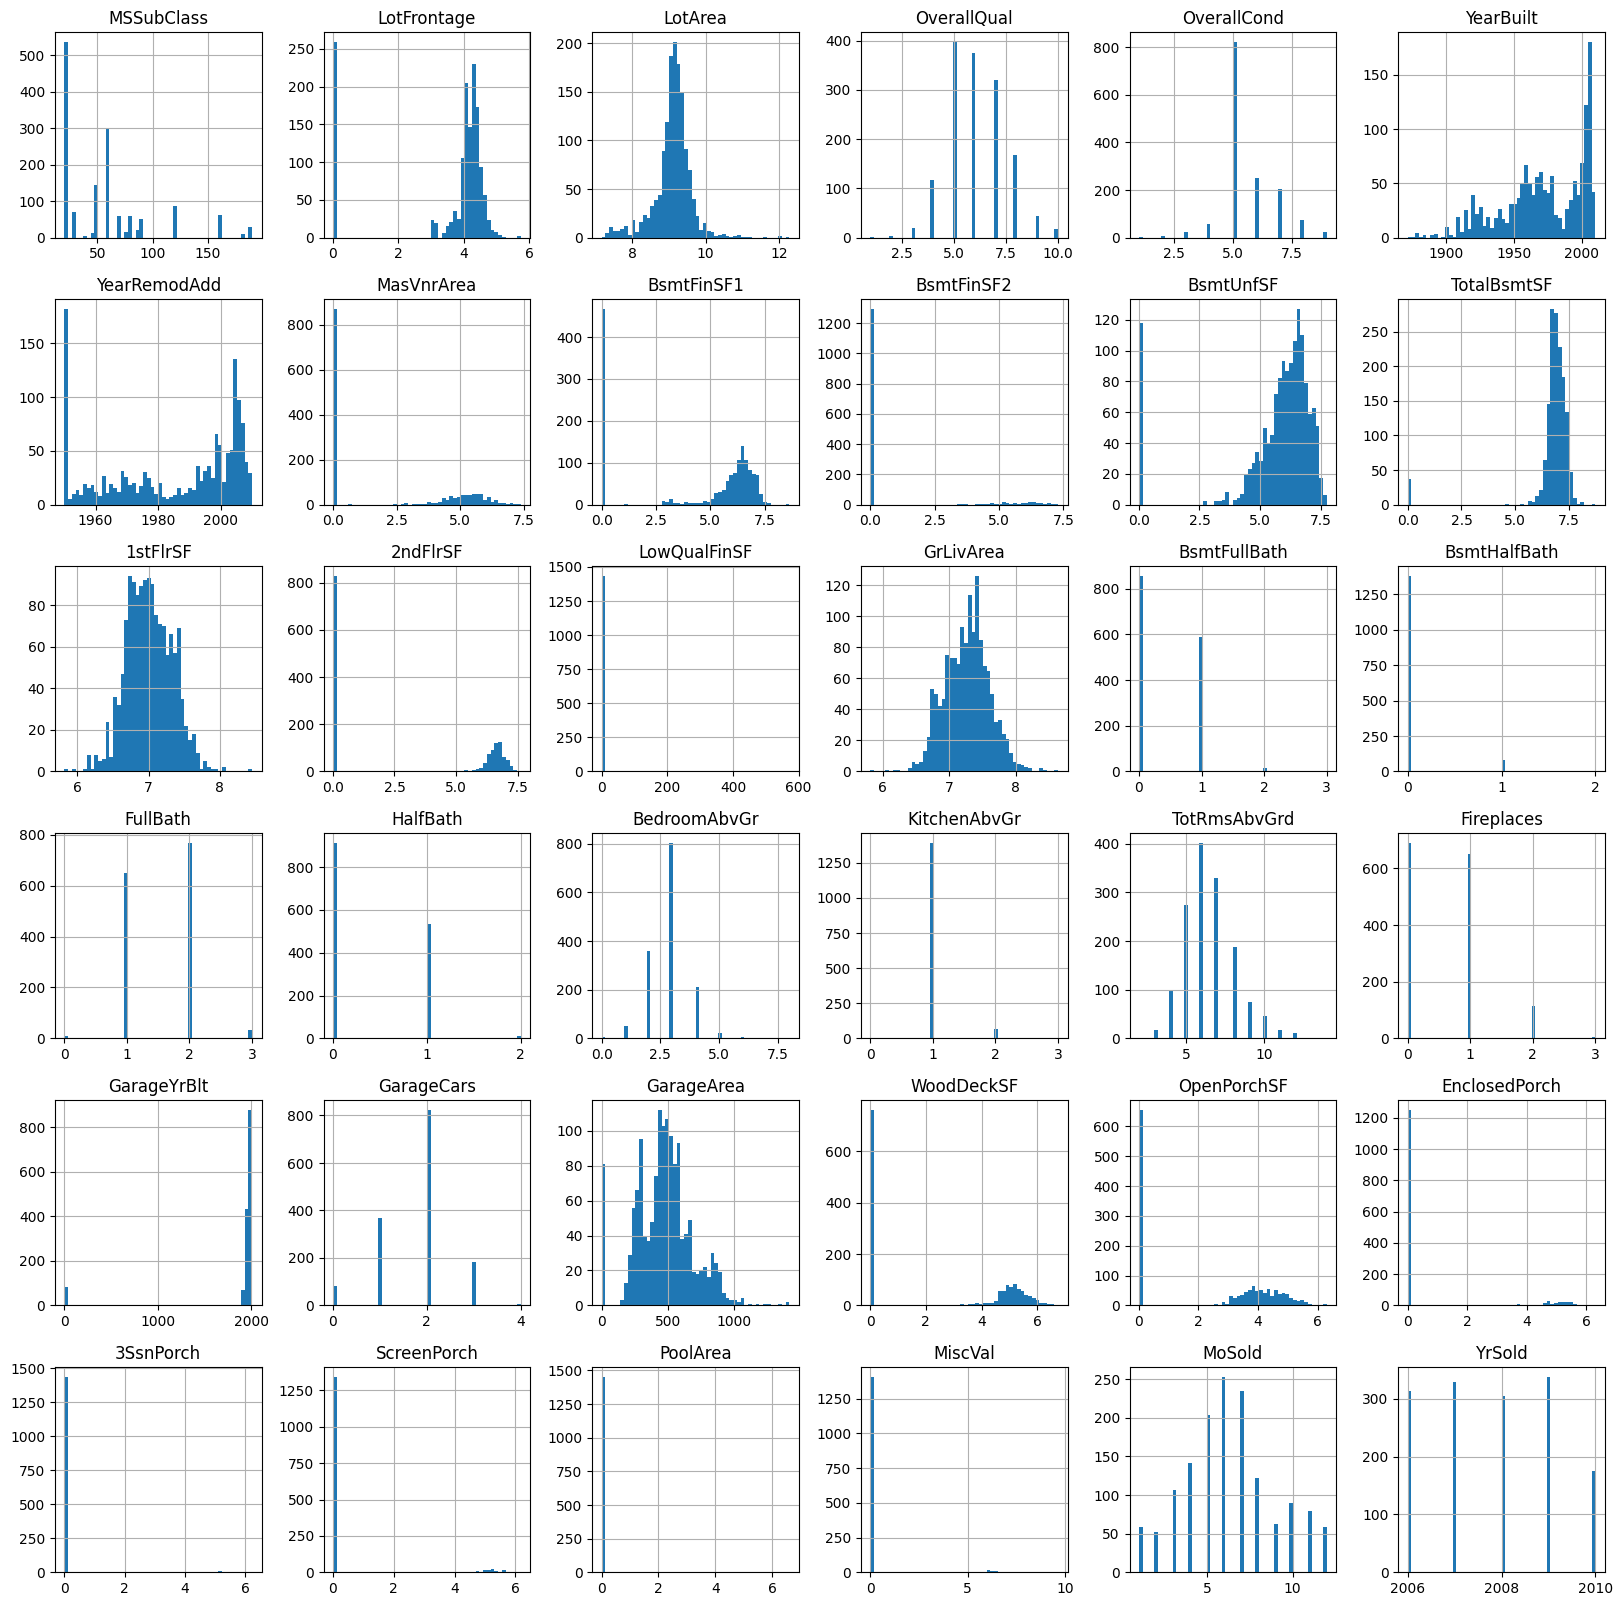

In [12]:
from src.schema import FORCE_NUMERICAL, FORCE_CATEGORICAL

num_cols = FORCE_NUMERICAL

cat_cols =FORCE_CATEGORICAL
# num_columns =  df_fe.select_dtypes(include='number').columns.tolist()
df_fe[num_cols].hist(bins=50, figsize=(20, 20));

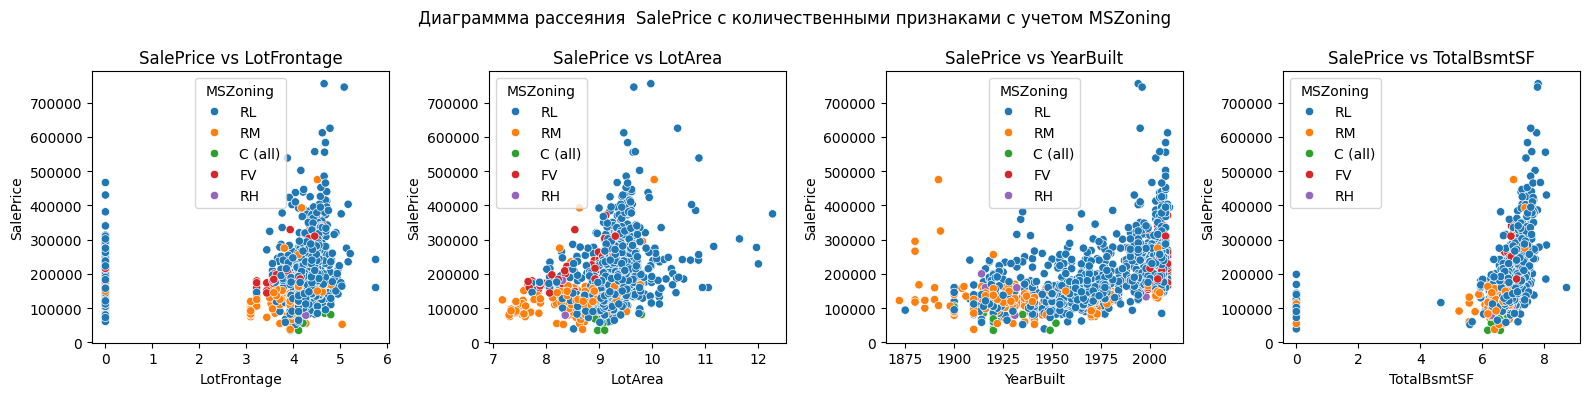

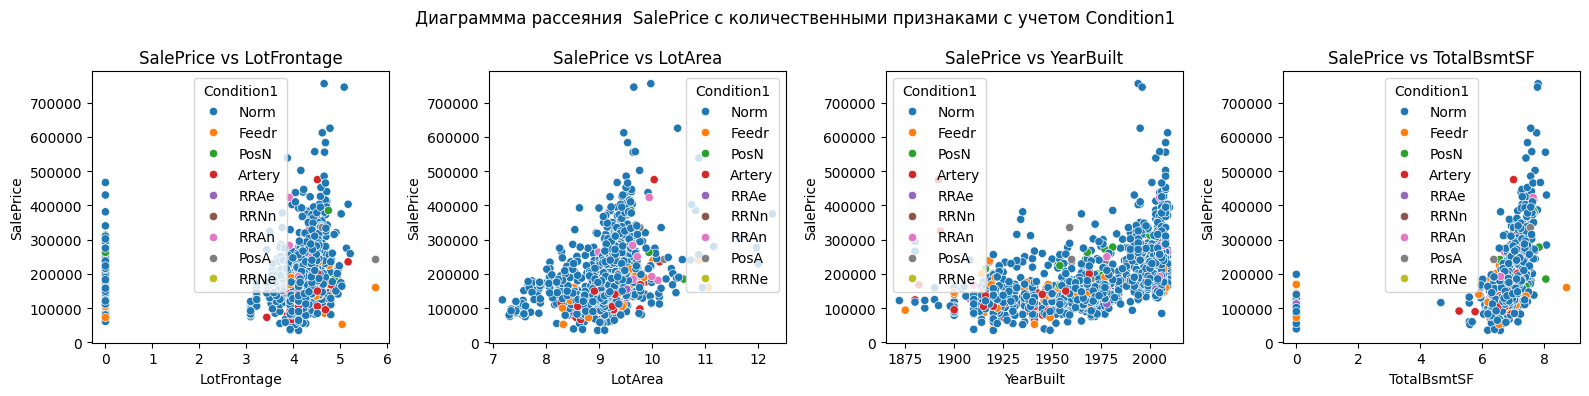

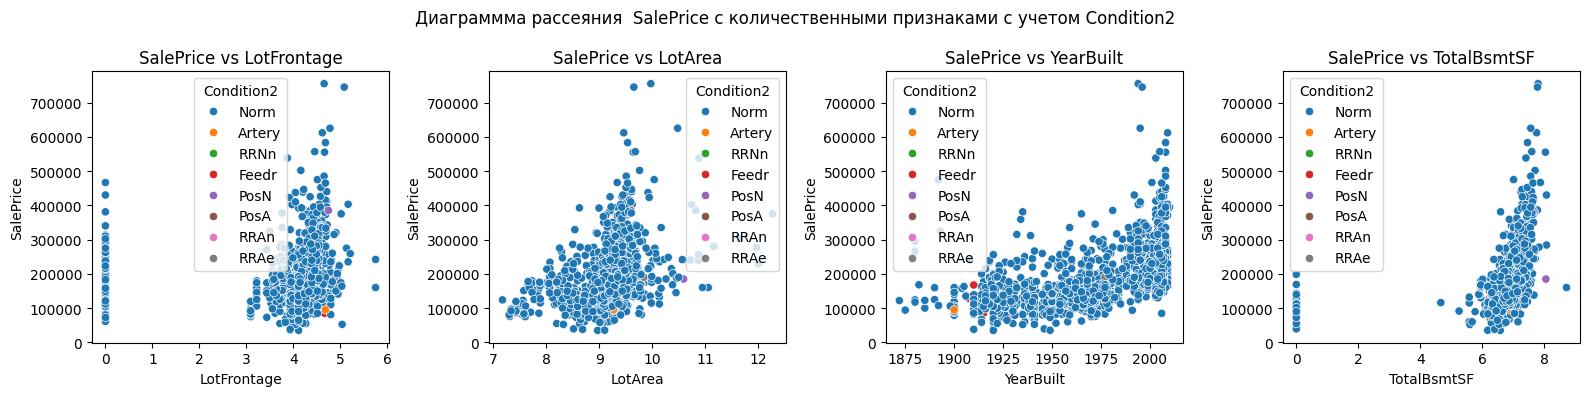

In [19]:
from src.schema import TARGET_COLUMN


def scatter_plt(hue):
    val_columns_ = ['LotFrontage', 'LotArea', 'YearBuilt', 'TotalBsmtSF']
    num_plots = len(val_columns_)

    # Создаем один ряд с num_plots подграфиками
    fig, axes = plt.subplots(1, num_plots, figsize=(num_plots * 4, 4))

    for i, col in enumerate(val_columns_):
        sns.scatterplot(data=df_fe, x=col, y=TARGET_COLUMN, hue=hue, ax=axes[i])
        axes[i].set_title(f'{TARGET_COLUMN} vs {col}')

    # Подгонка расстояния между графиками
    fig.suptitle(f'Диаграммма рассеяния  {TARGET_COLUMN} с количественными признаками с учетом ' + hue)
    plt.tight_layout()
    plt.show()
cols = ['MSZoning', 'Condition1', 'Condition2']
for col in cols:
    scatter_plt(col)
    

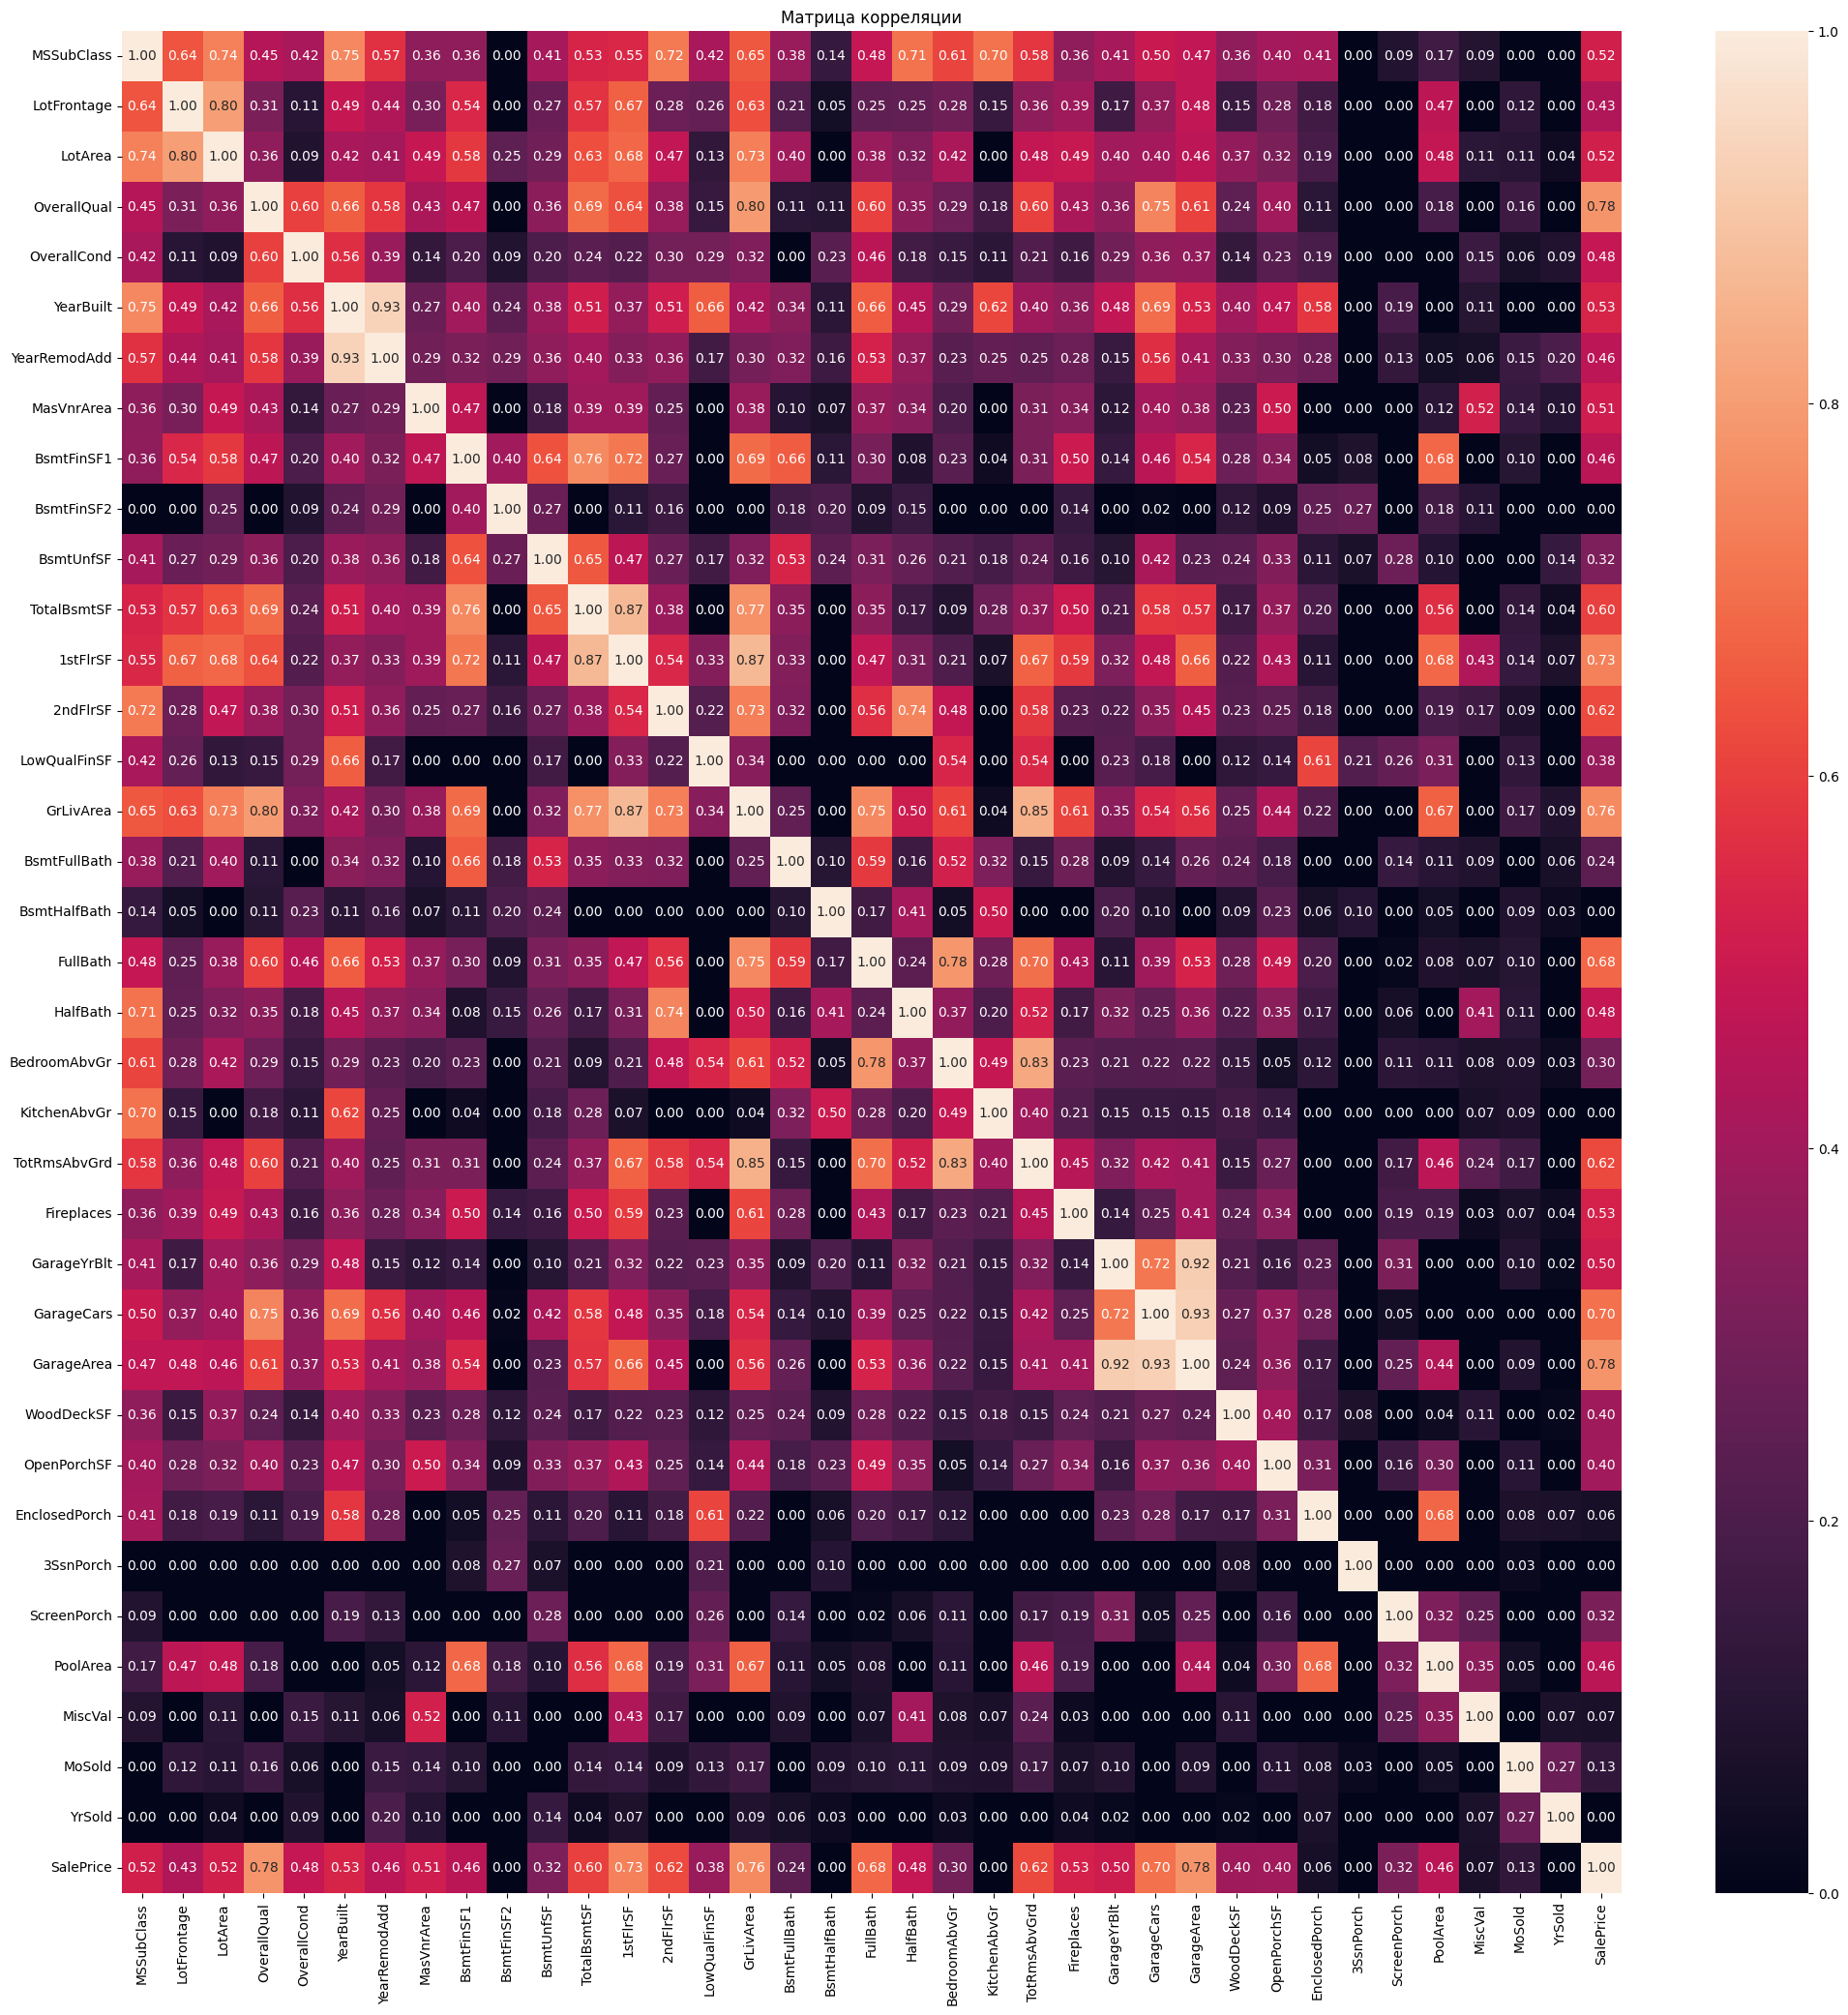

In [20]:
from src.utils import draw_phik_matrix
from src.schema import ID_COLUMN
import phik
draw_phik_matrix(df_fe, drop_columns=[])


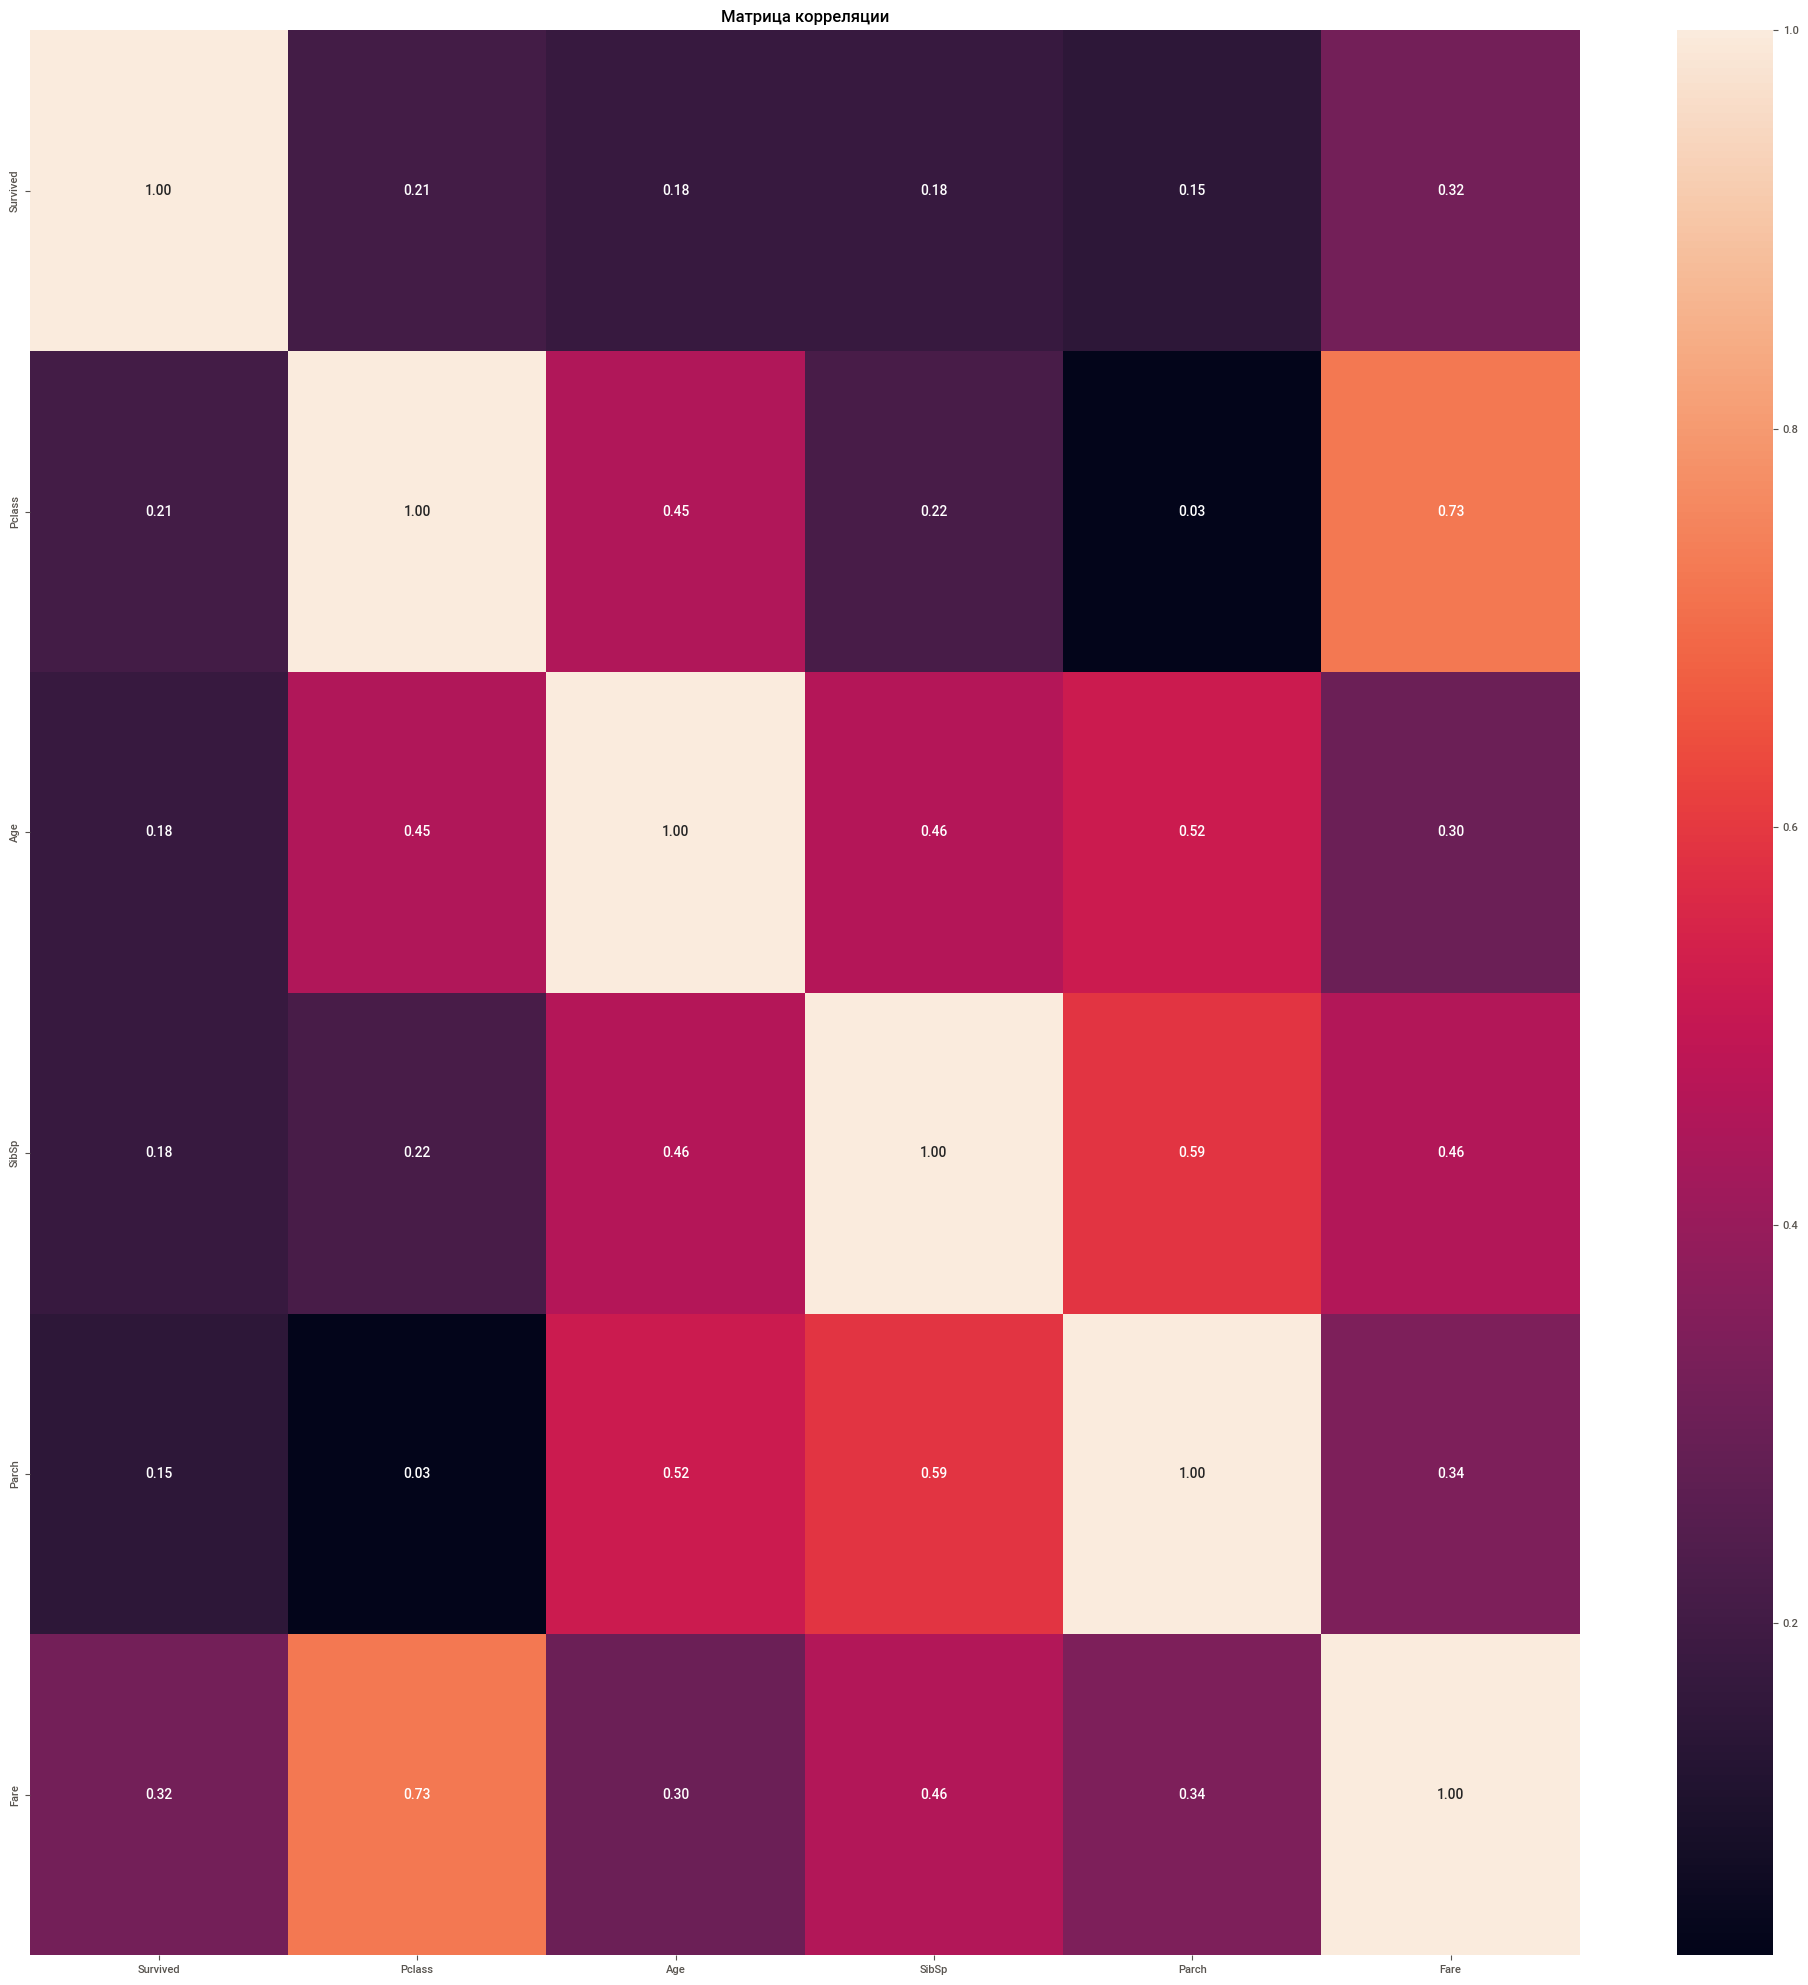

In [17]:
draw_phik_matrix(df, drop_columns=['PassengerId'])

In [24]:
path = config.paths.path_to_checkpoints / 'leaderboard.csv'
leaderboard = pd.read_csv(path)
leaderboard['score'] = leaderboard['score'].abs()
leaderboard = leaderboard[leaderboard['experiment_name']!=' test']

summary = (
    leaderboard
    .pivot_table(
        index='model_name',
        columns='experiment_name',
        values='score',
        aggfunc='min'
    )
)

summary['best_score'] = summary.min(axis=1)

display(summary.sort_values('best_score', ascending=False))

experiment_name,baseline,v1,v2,v3,best_score
model_name,,,,,
DNN_RANDOM,NaN,0.211087,NaN,NaN,0.211087
DNN,0.339993,0.199666,NaN,NaN,0.199666
KNN,0.165621,0.165422,0.161882,NaN,0.161882
Linear,0.156059,0.156059,0.156497,0.160954,0.156059
Ridge,0.151005,0.138651,0.154802,NaN,0.138651
RandomForest,0.142380,0.138055,0.143534,0.138093,0.138055
Lasso,0.137754,0.137754,0.155338,NaN,0.137754
ElasticNet,0.137126,0.136483,0.156289,0.156289,0.136483
GradientBoosting,0.122056,0.120006,0.135520,0.120109,0.120006


baseline - обучены модели c начальным гридом гиперпараметров
v1 - грид гиперпараметров расширеен
v2 - добавлен гиперпараметр отбор и обучениее только на статистичесски значимых парметрах
v3 - лоогарифмироованы некоторые числовые признаки
